In [8]:
import igraph as ig
import matplotlib.pyplot as plt
import os
import json
import pandas as pd
import itertools
from tqdm import tqdm
import math
import seaborn as sns

### **Leitura dos subreddits:**
```
data
|-    0
|     |-   subreddits
|     |    |-   subreddit1.json
|     |    |-   subreddit2.json
|     |    |-   ...
|     |    |-   subredditN.json
|-    1
|     |-   subreddits
|     |    |-   subreddit1.json
|     |    |-   subreddit2.json
|     |    |-   ...
|     |    |-   subredditN.json
|     ...
|-    N
|     |-   subreddits
|     |    |-   subreddit1.json
|     |    |-   subreddit2.json
|     |    |-   ...
|     |    |-   subredditN.json
```

In [9]:
#%%
rows = []
erros = []

# Itera por cada profundidade
for depth in range(3 + 1):
    dir_ = f"../data/raw/final/{depth}/subreddits"
    if not os.path.exists(dir_):
        continue
    for filename in os.listdir(dir_):
        if filename.endswith(".json"):
            path = os.path.join(dir_, filename)
            try:
                with open(path, "r", encoding="utf-8") as f:
                    posts = json.load(f)
                # Adiciona a profundidade em cada post para rastreabilidade
                for post in posts:
                    post["depth"] = depth
                rows.extend(posts)
            except json.JSONDecodeError:
                erros.append(path)

print(f"Arquivos com erro: {len(erros)}")
print(f"Posts carregados: {len(rows)}")
df = pd.DataFrame(rows)

Arquivos com erro: 0
Posts carregados: 1383518


#### Criação de um DataFrame para cada profundidade

In [10]:
df_0 = df[df['depth'] == 0]
df_1 = df[df['depth'] == 1]
df_2 = df[df['depth'] == 2]

#### Criação de um DataFrame moldado para o grafo

**Onde é criada uma linha para cada combinação de subreddits (Vértices) que compartilhem ao menos um autor (Arestas) em comum que fez publicações em ambos subreddits, sendo o Peso, a quantidade de autores que postaram nos dois subreddits**

In [11]:
#%%
subreddit_users = df_0.groupby('subreddit')['author'].unique().reset_index()

def get_subreddit_connections(df_grouped):
    # 1. Transformar em dicionário de sets para busca ultra rápida
    # Isso evita o uso de .isin() que é lento em loops
    sub_map = {row.subreddit: set(row.author) for row in df_grouped.itertuples()}
    
    subreddits = list(sub_map.keys())
    edge_list = []

    # 2. Usar itertools para evitar comparar o subreddit com ele mesmo
    # e evitar comparar (A,B) e depois (B,A) desnecessariamente
    for sub_a, sub_b in itertools.combinations(subreddits, 2):
        
        # O pulo do gato: interseção de sets é feita em nível de C no Python
        common_authors = sub_map[sub_a].intersection(sub_map[sub_b])
        weight = len(common_authors)
        
        if weight > 0:
            edge_list.append({
                'source': sub_a,
                'target': sub_b,
                'weight': weight
            })
    
    return pd.DataFrame(edge_list)

# Uso:
df_conexoes = get_subreddit_connections(subreddit_users)


In [12]:
df_conexoes

,source,target,weight
0,10thdentist,196,1
1,10thdentist,2007scape,1
2,10thdentist,2westerneurope4u,1
3,10thdentist,4chan,1
4,10thdentist,4tran4,1
...,...,...,...
123786,youonlifetime,zillennials,1
123787,youonlifetime,zzz_official,1
123788,zepbound,zillennials,1
123789,zepbound,zzz_official,1


---

### **Criação do Grafo a partir da lógica anterior**

In [13]:
g = ig.Graph.TupleList(
    df_conexoes.itertuples(index=False), 
    directed=False, 
    edge_attrs=['weight']
)

print(f"Nós: {g.vcount()}")
print(f"Arestas: {g.ecount()}")

Nós: 500
Arestas: 123791


---
### **Analisando a Distribuição de Grau**

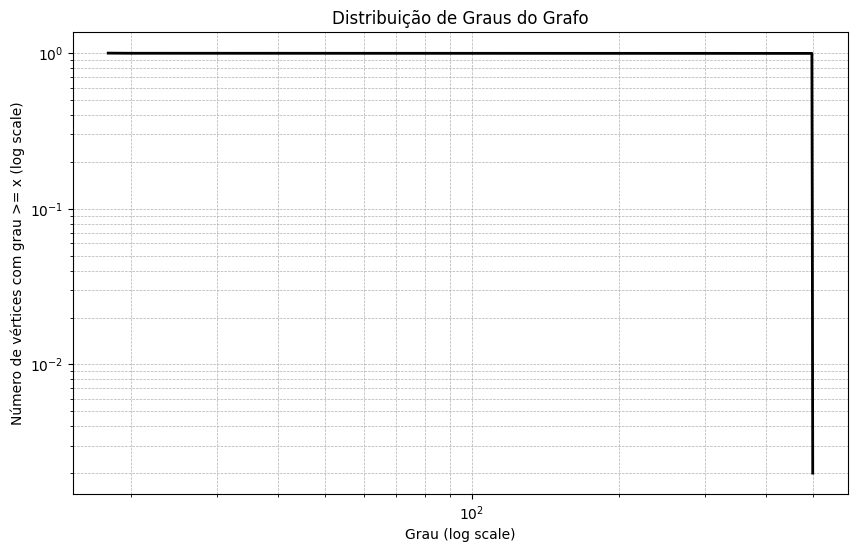

In [14]:
from collections import Counter

graus = g.degree() # Retorna o grau de cada vértice em uma lista

contagem_graus = Counter(graus) # Retorna um dicionário onde a chave é o grau e o valor é a contagem de vértices com esse grau
contagem_graus = sorted(contagem_graus.items()) # Ordena por grau (chave do dicionário) para facilitar a visualização

distribuicao_graus = {}
for grau, contagem in contagem_graus:
    distribuicao_graus[grau] = contagem/g.vcount() # Normaliza pela quantidade total de vértices para obter a distribuição de probabilidade

x = []
menos = 0
for grau, contagem in distribuicao_graus.items():
    x.append(sum(distribuicao_graus.values()) - menos) # Número de vértices com grau >= x (CCDF)
    menos += contagem

plt.figure(figsize=(10, 6))
plt.plot(list(distribuicao_graus.keys()), x, linestyle='-', color='black', linewidth=2)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Grau (log scale)')
plt.ylabel('Número de vértices com grau >= x (log scale)')
plt.title('Distribuição de Graus do Grafo')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.show()

/tmp/ipykernel_2975794/922417782.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=graus_labels, y=frequencias, palette="viridis")


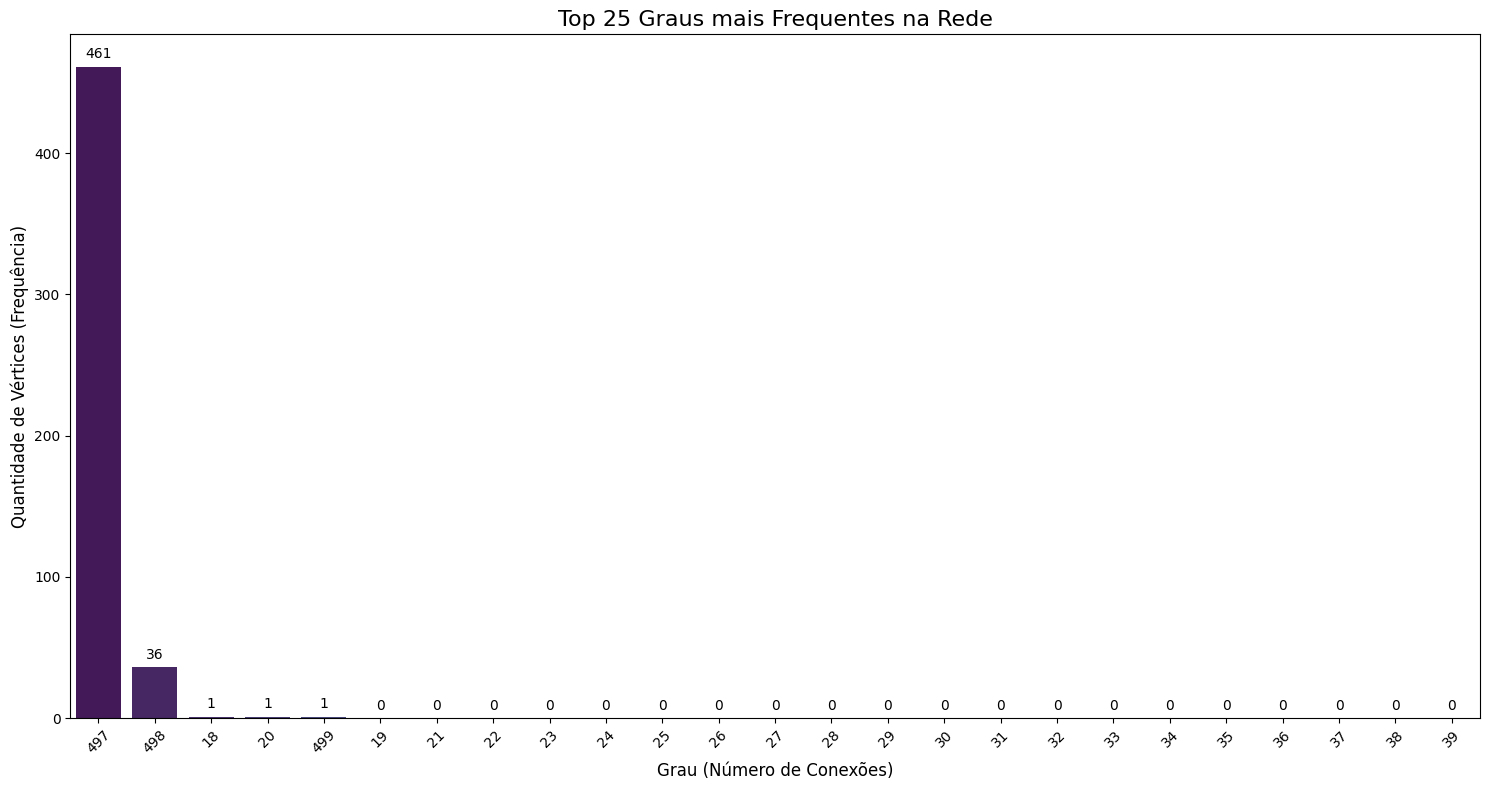

In [15]:
# Retorna um objeto de distribuição (lista de probabilidades)
dist = g.degree_distribution()
sorted_bins = sorted(dist.bins(), key=lambda x: x[2], reverse=True)

top_25 = sorted_bins[:25]
graus_labels = [str(int(b[0])) for b in top_25]
frequencias = [b[2] for b in top_25]

plt.figure(figsize=(15, 8))
ax = sns.barplot(x=graus_labels, y=frequencias, palette="viridis")

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.0f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points',
                fontsize=10)

plt.title("Top 25 Graus mais Frequentes na Rede", fontsize=16)
plt.xlabel("Grau (Número de Conexões)", fontsize=12)
plt.ylabel("Quantidade de Vértices (Frequência)", fontsize=12)
plt.xticks(rotation=45) # Inclina os nomes para não sobrepor
plt.tight_layout()
plt.savefig("../reports/degree_distribution.png", dpi=300)
plt.show()

---
### **Analisando o Coeficiente de Clustering**

In [10]:
cc = {}

for vertice in tqdm(g.vs, desc="Processando"):
    vizinhos = set(vertice.neighbors()) # Conjunto de vizinhos de um vértice
    num_vizinhos = len(vizinhos) # Número de vizinhos do vértice
    
    if num_vizinhos > 1:
        arestas_entre_vizinhos = 0
        for v1 in vizinhos:
            for v2 in vizinhos:
                if (v1.index < v2.index # Evita contar a mesma aresta duas vezes
                    and g.are_adjacent(v1, v2)): # Se vo vizinho v1 é adjacente ao vizinho v2, então 1 é somado às arestas entre vizinhos
                    arestas_entre_vizinhos += 1
        
        possiveis = (num_vizinhos * (num_vizinhos - 1)) / 2 # Número máximo de arestas entre os vizinhos de um vértice (/2 por ser grafo não direcionado)
        cc[vertice.index] = arestas_entre_vizinhos / possiveis # Coeficiente de clusterização é a razão entre as arestas existentes e as possíveis entre os vizinhos
    else:
        cc[vertice.index] = 0.0

Processando:   0%|          | 0/4451 [00:00<?, ?it/s]

Processando: 100%|██████████| 4451/4451 [51:59<00:00,  1.43it/s]  


In [12]:
with open("coeficiente_clusterizacao.json", "w") as f:
    json.dump(cc, f, indent=4)

In [19]:
df_cc = pd.Series(cc).reset_index()
df_cc.columns = ['vertex_index', 'clustering_coefficient']
df_cc["clustering_coefficient"].describe()

count    4451.000000
mean        0.733193
std         0.289522
min         0.000000
25%         0.417985
50%         0.919928
75%         0.982009
max         1.000000
Name: clustering_coefficient, dtype: float64

In [ ]:
cc_nativo = g.transitivity_local_undirected()
iguais = True
for idx, valor_manual in cc.items():
    valor_nativo = cc_nativo[idx]
    
    # math.isclose é melhor que '==' para números decimais (floats)}
    if not math.isclose(valor_manual, valor_nativo, rel_tol=1e-9):
        print(f"Diferença encontrada no vértice {idx}!")
        print(f"Manual: {valor_manual} | Nativo: {valor_nativo}")
        iguais = False
        break

if iguais:
    print("Sucesso! Seus cálculos manuais batem 100% com a biblioteca.")

Diferença encontrada no vértice 3676!
Manual: 0.0 | Nativo: nan


---
### **Analisando a Centralidade dos Vértices**

#### **1. Centralidade por Grau**

In [30]:
centralidade = {}
centralidade_por_peso = {}
pesos = g.es['weight']
total_pesos = sum(pesos)

for vertice in tqdm(g.vs, desc="Processando"):
    ci = vertice.degree() / (g.vcount() - 1)
    centralidade[vertice.index] = ci

    peso = 0
    for vizinho in vertice.neighbors():
        peso += g.es[g.get_eid(vertice.index, vizinho.index)]['weight']
    ci_peso =peso / total_pesos if total_pesos > 0 else 0
    centralidade_por_peso[vertice.index] = ci_peso

Processando:   0%|          | 0/4451 [00:00<?, ?it/s]

Processando: 100%|██████████| 4451/4451 [00:05<00:00, 749.66it/s] 


In [ ]:
df_centralidade_grau = pd.DataFrame({
    'vertex_index': list(centralidade.keys()),
    'degree_centrality': list(centralidade.values()),
    'weight_centrality': list(centralidade_por_peso.values())
})
df_centralidade_grau.to_csv("centralidade_grau.csv", index=False)

#### **2. Centralidade por eigenvector**

In [34]:
import numpy as np
from tqdm import tqdm

def eigenvector_centrality(graph, interations=100, tol=1e-6):
    N = graph.vcount()
    x = np.ones(N)

    for _ in tqdm(range(interations), desc="Calculando Centralidade de Eigenvector"):
        x_antigo = x.copy()
        novo_x = np.zeros(N)

        for aresta in graph.es:
            u = aresta.source
            v = aresta.target
            w = aresta['weight']

            novo_x[v] += x_antigo[v] * w
            novo_x[u] += x_antigo[u] * w
        
        norma = np.linalg.norm(novo_x)
        if norma > 0:
            x = novo_x / norma
        
        diff = np.linalg.norm(x - x_antigo)
        if diff < tol:
            break
    
    return x

centralidade_autovetor = eigenvector_centrality(g)


Calculando Centralidade de Eigenvector: 100%|██████████| 100/100 [04:54<00:00,  2.95s/it]


In [40]:
centralidade_autovetores_dict = {}
for idx, valor in enumerate(centralidade_autovetor):
    centralidade_autovetores_dict[idx] = valor

In [41]:
with open("centralidade_autovetor.json", "w") as f:
    json.dump(centralidade_autovetores_dict, f, indent=4)

In [44]:
g.vs['eigen'] = g.eigenvector_centrality(weights='weight')
eigen_nativo = g.vs['eigen']

diferencas = []

print(f"{'ID':<6} | {'Manual':<12} | {'Nativo':<12} | {'Erro Absoluto':<12}")
print("-" * 55)

for idx in range(len(eigen_nativo)):
    v_manual = centralidade_autovetores_dict[idx]
    v_nativo = eigen_nativo[idx]
    erro = abs(v_manual - v_nativo)
    diferencas.append(erro)
    
    # Mostrar apenas os 5 primeiros e os que tiverem erro maior que 1e-5
    if idx < 5:
        print(f"{idx:<6} | {v_manual:<12.8f} | {v_nativo:<12.8f} | {erro:<12.8e}")

# Estatísticas Gerais
print("-" * 55)
print(f"Erro Médio: {np.mean(diferencas):.2e}")
print(f"Erro Máximo: {np.max(diferencas):.2e}")

ID     | Manual       | Nativo       | Erro Absoluto
-------------------------------------------------------
0      | 0.00000000   | 0.77389406   | 7.73894058e-01
1      | 0.00000002   | 0.90541314   | 9.05413127e-01
2      | 0.00000000   | 0.77784115   | 7.77841148e-01
3      | 0.00000000   | 0.80044662   | 8.00446618e-01
4      | 0.00000000   | 0.84926369   | 8.49263692e-01
-------------------------------------------------------
Erro Médio: 4.25e-01
Erro Máximo: 9.86e-01


---
### **Figura da rede com os tamanhos dos vértices proporcionais às centralidades**



In [39]:
def plot_graph(graph, centralidade_dict, title="Ecossistema de comunidades misóginas - Projeção de Autores"):
    fig, ax = plt.subplots(figsize=(12, 12))

    style = {}
    valores = [centralidade_dict[v.index] for v in graph.vs]
    max_valor = max(valores) if valores else 1
    style["vertex_size"] = [v / max_valor * 30 + 5 for v in valores] 

    style["vertex_color"] = "red"
    style["vertex_frame_width"] = 0.5
    style["vertex_frame_color"] = "black"

    threshold = np.percentile(valores, 99.5)
    style["vertex_label"] = [v['name'] if centralidade_dict[v.index] >= threshold else None for v in graph.vs]
    style["vertex_label_size"] = 10
    style["vertex_label_dist"] = 1.2

    pesos = graph.es['weight']
    max_peso = max(pesos) if pesos else 1
    style["edge_width"] = [np.log1p(w) * 0.5 for w in pesos]
    style["edge_color"] = "rgba(200, 200, 200, 0.4)" 
    style["edge_curved"] = 0.1

    layout = graph.layout("fr") # Fruchterman-Reingold também é excelente
    style["layout"] = layout
    
    ig.plot(
        graph,
        target=ax,
        **style
    )

    ax.set_title(title, fontsize=16)
    plt.axis('off')
    
    plt.savefig(title, dpi=300, bbox_inches='tight')
    print(f"Gráfico salvo como '{title}'")
    plt.show()
    
plot_graph(g, centralidade_autovetores_dict, "Centralidade de Autovetor - Manosphere")

NameError: name 'centralidade_autovetores_dict' is not defined

In [8]:

g.vs['degree'] = g.degree()
g.vs['eigen'] = g.eigenvector_centrality(weights='weight')

# 3. Preparar o Plot
fig, ax = plt.subplots(figsize=(10, 10)) 

# Normalizar o tamanho dos vértices proporcional à centralidade de Eigenvector
sizes = [v * 30 + 5 for v in g.vs['eigen']] 

ig.plot(
    g,
    target=ax,
    layout="fr",          
                           
    vertex_size=sizes,      # TAMANHO PROPORCIONAL À CENTRALIDADE
    vertex_color="red",
    vertex_frame_width=0.5,
    vertex_label=g.vs["name"] if g.vcount() < 100 else None, 
    vertex_label_size=8,
    edge_width=[w * 0.5 for w in g.es['weight']], # Espessura da linha proporcional ao tráfego
    edge_color="gray",
    edge_curved=0.2         # Deixa as linhas levemente curvas, fica mais estético
)

plt.title("Ecossistema de Comunidades Misóginas - Projeção de Autores")
plt.axis('off')
plt.show()

: 

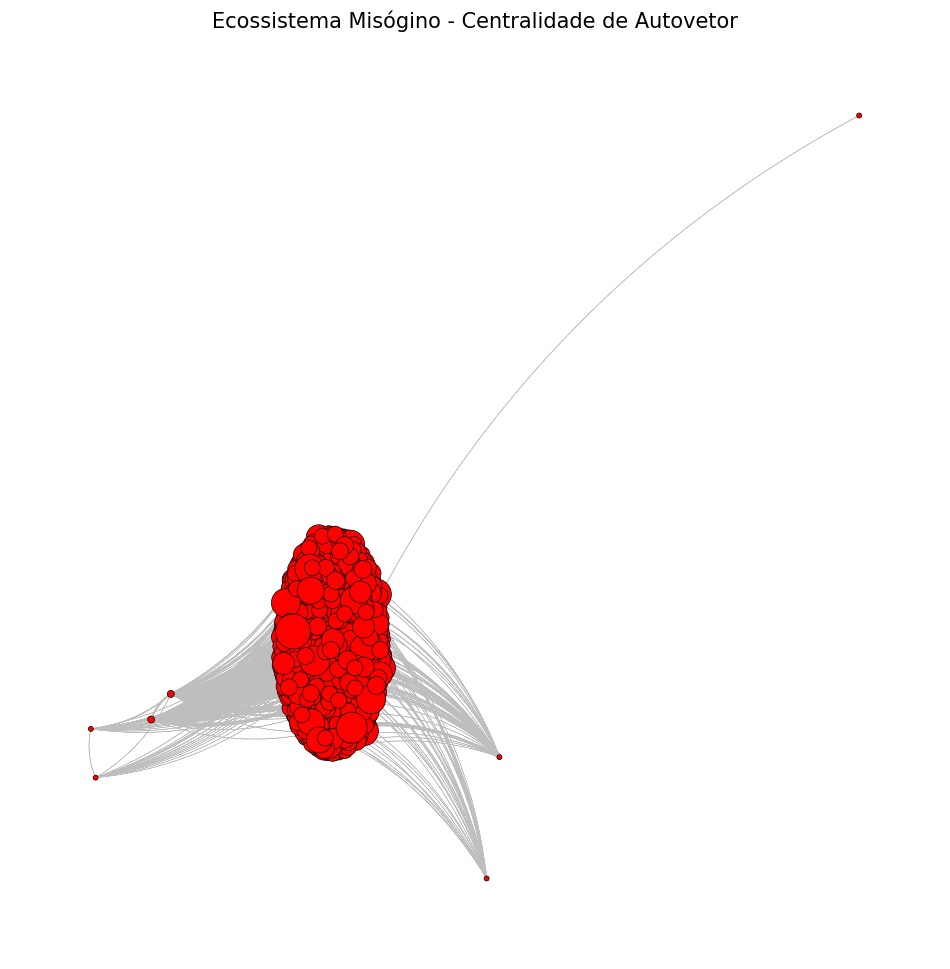

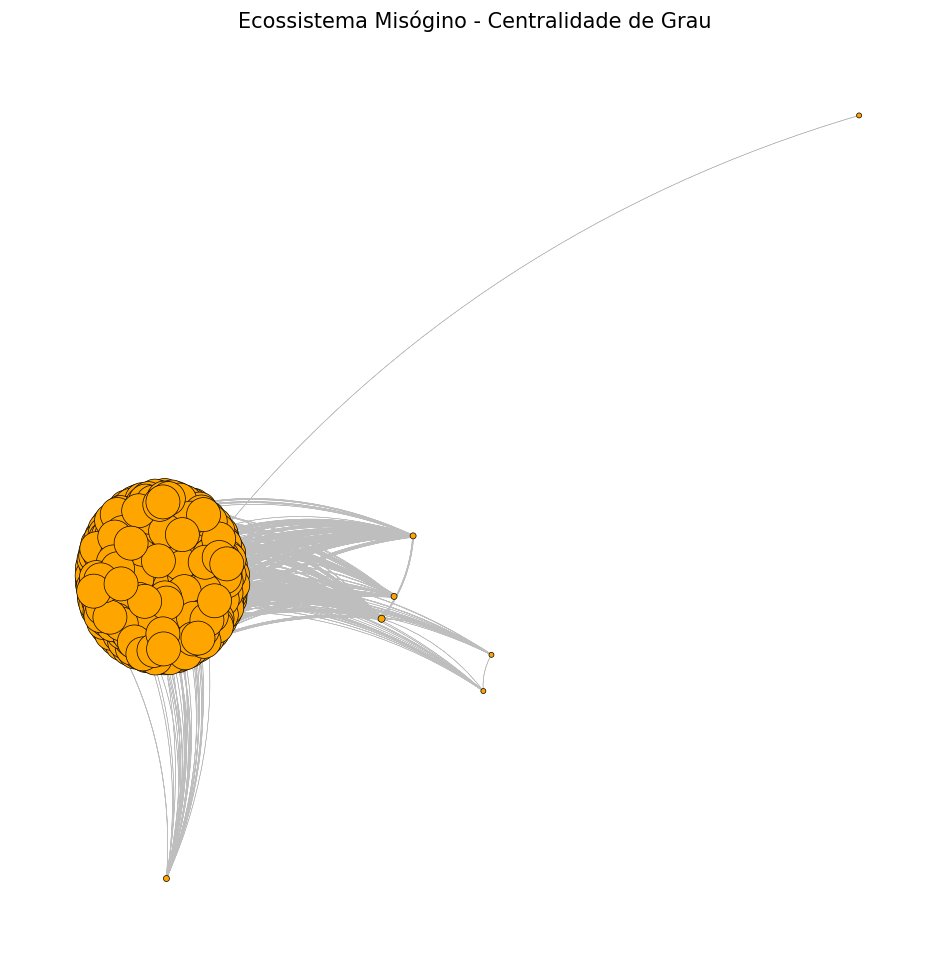

In [8]:
def plot_network(graph, centrality_attr, title="Rede de Subreddits", node_color="red"):
    fig, ax = plt.subplots(figsize=(12, 12)) 

    centrality_values = graph.vs[centrality_attr]
    [v * 30 + 5 for v in g.vs['eigen']] 
    if centrality_attr == 'eigen':
        sizes = [v * 30 + 5 for v in g.vs['eigen']] 
    else:
        # Para grau, normalizamos para não ficarem gigantescos
        max_val = max(centrality_values) if centrality_values else 1
        sizes = [(v / max_val) * 30 + 5 for v in centrality_values]

    ig.plot(
        graph,
        target=ax,
        layout=graph.layout("fr"), # Fruchterman-Reingold
        vertex_size=sizes, # TAMANHO PROPORCIONAL À CENTRALIDADE
        vertex_color=node_color,
        vertex_frame_width=0.5,
        vertex_label=graph.vs["name"] if graph.vcount() < 50 else None,
        vertex_label_size=8,
        edge_width=[w * 0.4 for w in graph.es['weight']], 
        edge_color="gray",
        edge_curved=0.2,
        alpha=0.7
    )

    # 4. Finalização
    plt.title(title, fontsize=15)
    plt.axis('off')
    plt.show()

# --- Como usar a função ---

# Certifique-se de que os atributos existem no grafo antes de chamar
g.vs['degree'] = g.degree()
g.vs['eigen'] = g.eigenvector_centrality(weights='weight')

# Plotando com Autovetor (Influência)
plot_network(g, 'eigen', title="Ecossistema Misógino - Centralidade de Autovetor")

# Plotando com Grau (Popularidade Direta)
plot_network(g, 'degree', title="Ecossistema Misógino - Centralidade de Grau", node_color="orange")

---
#### **Juntando Tudo**

In [72]:
df_autovet = pd.read_json("centralidade_autovetor.json", typ='series').reset_index()
df_cc = pd.read_json("coeficiente_clusterizacao.json", typ='series').reset_index()
df_cen_grau = pd.read_csv("centralidade_grau.csv")

In [73]:
df_autovet = df_autovet.reset_index().rename(columns={'index': 'vertex_index', 0: 'eigenvector_centrality'})
df_cc = df_cc.reset_index().rename(columns={'index': 'vertex_index', 0: 'clustering_coef'})

df_final = pd.merge(df_cen_grau, df_autovet, on='vertex_index', how='outer')
df_final = pd.merge(df_final, df_cc, on='vertex_index', how='outer')

In [74]:
colunas_ordenadas = [
    'vertex_index', 
    'degree_centrality', 
    'weight_centrality', 
    'eigenvector_centrality',           
    'clustering_coef'        
]
df_final = df_final[colunas_ordenadas]
df_final.to_csv("metricas_finais_rede_manual.csv", index=False)

In [75]:
df_final.head()

,vertex_index,degree_centrality,weight_centrality,eigenvector_centrality,clustering_coef
0,0,0.504719,0.000765,1.097164e-19,0.997454
1,1,0.593483,0.000991,1.828878e-08,0.778039
2,2,0.506292,0.000771,2.327461e-19,0.991743
3,3,0.519775,0.000814,5.626474e-17,0.942689
4,4,0.529663,0.000894,6.011844e-13,0.910703
